# Pandas Primer

A quick reference for the pandas basics you'll need throughout the ML course. This is not a deep dive - just the essentials to get you comfortable loading, exploring, and manipulating tabular data.

We'll use the Titanic dataset since you've already seen it in Lesson 1.

In [ ]:
# Setup - run this first
# If you're using the Colab extension in VS Code, upload the repo's data/ folder to the runtime:
#   Right-click the 'data' folder in VS Code -> "Upload to Colab Session"
from pathlib import Path
try:
    import google.colab
    DATA_PATH = Path('/content/data')
except ImportError:
    DATA_PATH = Path('../../data')
print(f"Data path: {DATA_PATH}")

In [1]:
import pandas as pd
import numpy as np

print(f"pandas version: {pd.__version__}")

pandas version: 2.3.3


## Loading Data

The most common way to get data into pandas is from a CSV file. The result is a **DataFrame** - a table with rows and columns.

In [2]:
# Load a CSV file into a DataFrame
df = pd.read_csv(DATA_PATH / 'titanic' / 'titanic.csv')

# How big is it?
print(f"Shape: {df.shape}")
print(f"  {df.shape[0]} rows (passengers)")
print(f"  {df.shape[1]} columns (features)")

Shape: (891, 12)
  891 rows (passengers)
  12 columns (features)


## First Look at the Data

These are the commands you'll run every time you load a new dataset.

In [3]:
# First 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Last 3 rows
df.tail(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
# Column names, types, and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# Summary statistics for numeric columns
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


`.describe()` gives you the count, mean, std, min, max, and quartiles for every numeric column in one call. Scan this to spot obvious issues: are there negative ages? Is the max fare suspiciously high? Are counts lower than expected (meaning missing values)?

In [7]:
# Just the column names
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [8]:
# Data types
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


## Selecting Data

You'll constantly need to grab specific columns, rows, or subsets.

In [9]:
# Single column (returns a Series)
ages = df['Age']
print(type(ages))
ages.head()

<class 'pandas.core.series.Series'>


0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
Name: Age, dtype: float64

In [10]:
# Multiple columns (returns a DataFrame)
subset = df[['Name', 'Sex', 'Age', 'Survived']]
subset.head()

,Name,Sex,Age,Survived
0,"Braund, Mr. Owen Harris",male,22.0,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1
2,"Heikkinen, Miss. Laina",female,26.0,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1
4,"Allen, Mr. William Henry",male,35.0,0


In [11]:
# Filter rows by condition
women = df[df['Sex'] == 'female']
print(f"Women: {len(women)} passengers")

# Multiple conditions (use & for AND, | for OR, wrap each in parentheses)
rich_women = df[(df['Sex'] == 'female') & (df['Fare'] > 50)]
print(f"Women with fare > 50: {len(rich_women)} passengers")

Women: 314 passengers
Women with fare > 50: 87 passengers


In [12]:
# Select by position (iloc) or by label (loc)
print("Row 0:", df.iloc[0]['Name'])
print("Rows 10-12:")
df.iloc[10:13][['Name', 'Age', 'Survived']]

Row 0: Braund, Mr. Owen Harris
Rows 10-12:


,Name,Age,Survived
10,"Sandstrom, Miss. Marguerite Rut",4.0,1
11,"Bonnell, Miss. Elizabeth",58.0,1
12,"Saundercock, Mr. William Henry",20.0,0


## Missing Values

Real data is messy. Columns often have missing values (NaN). You need to know how to find them and deal with them.

In [13]:
# Count missing values per column
missing = df.isna().sum()
missing[missing > 0]

Age         177
Cabin       687
Embarked      2
dtype: int64

In [14]:
# As percentages
missing_pct = (df.isna().sum() / len(df) * 100).round(1)
missing_pct[missing_pct > 0]

Age         19.9
Cabin       77.1
Embarked     0.2
dtype: float64

In [15]:
# Option 1: Drop rows with missing values
df_dropped = df.dropna(subset=['Age'])
print(f"Before: {len(df)} rows, After dropping missing Age: {len(df_dropped)} rows")

# Option 2: Fill missing values
df_filled = df.copy()
df_filled['Age'] = df_filled['Age'].fillna(df_filled['Age'].median())
print(f"Missing ages after fill: {df_filled['Age'].isna().sum()}")

Before: 891 rows, After dropping missing Age: 714 rows
Missing ages after fill: 0


## Basic Operations

Common things you'll do with columns.

In [16]:
# Count unique values in a column
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [17]:
# Unique values
print(f"Unique classes: {df['Pclass'].unique()}")
print(f"Number of unique embark points: {df['Embarked'].nunique()}")

Unique classes: [3 1 2]
Number of unique embark points: 3


In [18]:
# Basic math on columns
print(f"Average age:  {df['Age'].mean():.1f}")
print(f"Median fare:  {df['Fare'].median():.2f}")
print(f"Oldest:       {df['Age'].max():.0f}")
print(f"Total fare:   ${df['Fare'].sum():,.0f}")

Average age:  29.7
Median fare:  14.45
Oldest:       80
Total fare:   $28,694


In [19]:
# Create new columns
df['FamilySize'] = df['SibSp'] + df['Parch']
df[['Name', 'SibSp', 'Parch', 'FamilySize']].head()

,Name,SibSp,Parch,FamilySize
0,"Braund, Mr. Owen Harris",1,0,1
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0,1
2,"Heikkinen, Miss. Laina",0,0,0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0,1
4,"Allen, Mr. William Henry",0,0,0


## Groupby

Split data into groups, apply a function, combine results. This is how you answer questions like "what's the survival rate by gender?" 

In [20]:
# Average survival rate by sex
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [21]:
# Average fare by class
df.groupby('Pclass')['Fare'].mean().round(2)

Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64

In [22]:
# Multiple aggregations
df.groupby('Pclass').agg(
    passengers=('PassengerId', 'count'),
    survival_rate=('Survived', 'mean'),
    avg_age=('Age', 'mean'),
    avg_fare=('Fare', 'mean')
).round(2)

,passengers,survival_rate,avg_age,avg_fare
Pclass,,,,
1,216,0.63,38.23,84.15
2,184,0.47,29.88,20.66
3,491,0.24,25.14,13.68


## Sorting

In [23]:
# Sort by a column
df.sort_values('Fare', ascending=False)[['Name', 'Fare', 'Pclass']].head()

,Name,Fare,Pclass
737,"Lesurer, Mr. Gustave J",512.3292,1
679,"Cardeza, Mr. Thomas Drake Martinez",512.3292,1
258,"Ward, Miss. Anna",512.3292,1
438,"Fortune, Mr. Mark",263.0000,1
88,"Fortune, Miss. Mabel Helen",263.0000,1


## Mapping and Replacing Values

ML models need numbers, not text. You'll often convert categorical columns.

In [24]:
# Convert text to numbers
df['Sex_numeric'] = df['Sex'].map({'male': 1, 'female': 0})
df[['Name', 'Sex', 'Sex_numeric']].head()

,Name,Sex,Sex_numeric
0,"Braund, Mr. Owen Harris",male,1
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0
2,"Heikkinen, Miss. Laina",female,0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0
4,"Allen, Mr. William Henry",male,1


## Quick Plotting

Pandas has built-in plotting. Good for quick exploration - you'll use matplotlib for anything more polished.

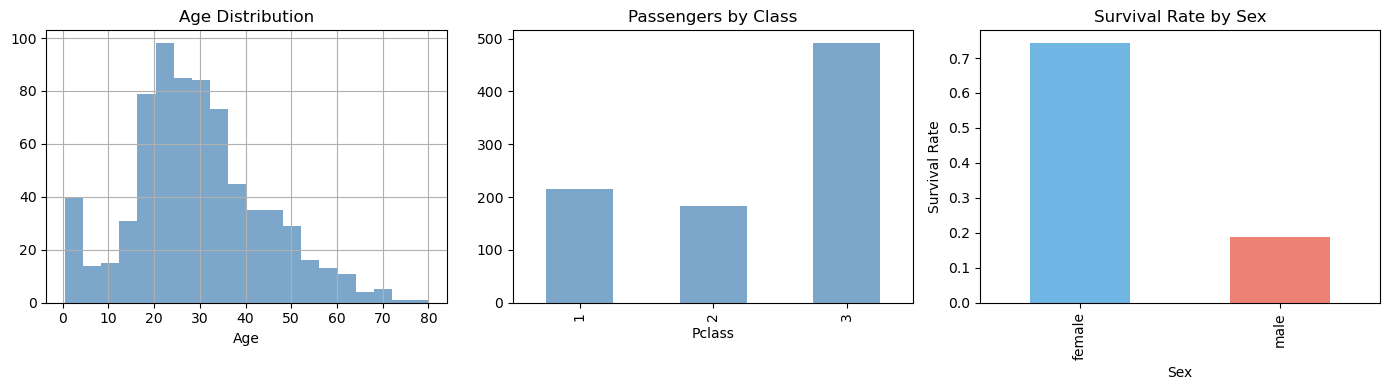

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df['Age'].hist(bins=20, ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

df['Pclass'].value_counts().sort_index().plot.bar(ax=axes[1], color='steelblue', alpha=0.7)
axes[1].set_title('Passengers by Class')

df.groupby('Sex')['Survived'].mean().plot.bar(ax=axes[2], color=['#3498db', '#e74c3c'], alpha=0.7)
axes[2].set_title('Survival Rate by Sex')
axes[2].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

## Apply (Custom Functions)

When built-in methods aren't enough, `.apply()` lets you run any function on each row or column.

In [26]:
# Extract title from name
def get_title(name):
    return name.split(',')[1].split('.')[0].strip()

df['Title'] = df['Name'].apply(get_title)
df['Title'].value_counts().head(8)

Title
Mr        517
Miss      182
Mrs       125
Master     40
Dr          7
Rev         6
Col         2
Mlle        2
Name: count, dtype: int64

## Quick Reference

| What you want | Code |
|---|---|
| Load CSV | `pd.read_csv('file.csv')` |
| First N rows | `df.head(N)` |
| Shape | `df.shape` |
| Column types | `df.dtypes` |
| Summary stats | `df.describe()` |
| Missing values | `df.isna().sum()` |
| Select column | `df['col']` |
| Filter rows | `df[df['col'] > 5]` |
| Value counts | `df['col'].value_counts()` |
| Group + aggregate | `df.groupby('col')['other'].mean()` |
| Sort | `df.sort_values('col')` |
| New column | `df['new'] = df['a'] + df['b']` |
| Drop column | `df.drop('col', axis=1)` |
| Drop missing | `df.dropna()` |
| Fill missing | `df['col'].fillna(value)` |
| Map values | `df['col'].map({'a': 1, 'b': 2})` |
| Apply function | `df['col'].apply(func)` |

That's it. This covers 90% of what you'll need for the course. You'll pick up the rest as you go - and remember, you can always ask an agent to help with pandas syntax.